# CS6140 Machine Learning — Fall 2026
# HW1 Starter — Closed-form Regression, Decision Trees, Boosted Trees, KNN

This notebook implements `HW1_26F.html`. For each problem you'll first solve it with a
well-known library (a sanity-check baseline), then implement the same thing from scratch and
evaluate it exactly the same way, so your two numbers should land right next to each other once
everything is filled in.

**Problems 1-4 (required):**
1. Closed-form linear regression + Ridge (Housing, Spambase)
2. Decision / regression tree from scratch (Spambase, Housing)
3. Boosted regression trees, fit to residuals (Housing)
4. KNN / fixed-window similarity classifiers (Spambase, MNIST)

**Problems 5-6 (optional, no credit):**
5. Second-order (Newton) boosting from the XGBoost paper -- a self-study mini-project (see
   `HW1_26F.html` for the reading + LLM-assisted implementation + no-LLM write-up structure).
6. Does boosting confidence track KNN neighborhood consistency? -- a small research study that
   reuses models built in Problems 3-5.

**How to work through this notebook.** Everything runs except the lines marked
`### TODO_STUDENT ###` — those have their code replaced with a `...` placeholder and a one-line
description of what to implement there. Read the surrounding (working) code and the markdown
above each section for context, then replace each `...` with real code. A cell with a `...` in it
will raise a `SyntaxError` or produce obviously wrong output until you fill it in — that's
expected, not a bug. Work top to bottom: later cells (and later problems) depend on earlier
classes (e.g. Problem 3's boosting reuses Problem 2's `DecisionTree`; Problem 6 reuses models from
Problems 3-5), so finish each `TODO` before moving on to the next one that uses it. Once a
"library baseline" cell's TODOs are filled in and run, the printed number is a target: your
matching "from scratch" implementation just below it should land on (or very near) the same
value.

Datasets are read from the shared course `data/` folder (paths are relative to
`1_intro_DT_RULES_REG/hw1/`, i.e. two levels up -- launch Jupyter from this notebook's own
directory, or the relative path won't resolve).

**Requirements (Problems 1-4 only -- Problems 5-6 are optional/no-credit and not required for
either of these).**
1. Fill in every `TODO_STUDENT` blank in Problems 1-4 according to the algorithm steps covered in
   lecture and the linked materials, and make sure the notebook runs top to bottom **through the
   end of Problem 4** without errors. (Problems 5-6's cells come after Problem 4 and contain their
   own, separate TODOs -- leaving those unfilled does not block Problems 1-4 from running; you
   simply stop reading/running before them if you're skipping the optional work.)
2. Understand the *whole* notebook through Problem 4 — including the provided/given code, not just
   the blanks you filled in — well enough to explain any part of it during office hours.


In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error as mse_loss
from sklearn.metrics.pairwise import pairwise_distances, rbf_kernel, polynomial_kernel

DATA = "../data"
np.random.seed(42)


## Data loading

Housing comes pre-split (regression). Spambase is one file, so we split it ourselves. MNIST uses the 200-dim Haar-feature extraction (`mnist_haar_bingyu`) so that KNN's pairwise distances stay cheap enough to run on a laptop.

In [46]:
# ---- Housing (regression): already split into train/test by the course ----
train_housing = np.loadtxt(f"{DATA}/housing_train.txt")
test_housing = np.loadtxt(f"{DATA}/housing_test.txt")

X_train_housing, y_train_housing = train_housing[:, :-1], train_housing[:, -1]
X_test_housing, y_test_housing = test_housing[:, :-1], test_housing[:, -1]

# standardize using train statistics only
housing_scaler = StandardScaler().fit(X_train_housing)
X_train_housing = housing_scaler.transform(X_train_housing)
X_test_housing = housing_scaler.transform(X_test_housing)

print("Housing train:", X_train_housing.shape, " test:", X_test_housing.shape)


Housing train: (433, 13)  test: (74, 13)


In [47]:
# ---- Spambase (binary classification): one file, we split it ----
spam_raw = np.loadtxt(f"{DATA}/spambase/spambase.data", delimiter=",")
X_spam, y_spam = spam_raw[:, :-1], spam_raw[:, -1]

X_train_spam, X_test_spam, y_train_spam, y_test_spam = train_test_split(
    X_spam, y_spam, test_size=0.2, random_state=42)

spam_scaler = StandardScaler().fit(X_train_spam)
X_train_spam = spam_scaler.transform(X_train_spam)
X_test_spam = spam_scaler.transform(X_test_spam)

print("Spambase train:", X_train_spam.shape, " test:", X_test_spam.shape)


Spambase train: (3680, 57)  test: (921, 57)


In [48]:
# ---- MNIST (Haar features, for KNN): pre-extracted 200-dim features ----
# Subsample the training set (KNN is O(n_train) per query, and this is a from-scratch
# implementation, not a KD-tree) so a laptop can run every (k, distance) combination below.
X_train_digits_full = np.loadtxt(f"{DATA}/mnist_haar_bingyu/training_image.txt", delimiter=",")
y_train_digits_full = np.loadtxt(f"{DATA}/mnist_haar_bingyu/training_label.txt", delimiter=",")
X_test_digits_full = np.loadtxt(f"{DATA}/mnist_haar_bingyu/testing_image.txt", delimiter=",")
y_test_digits_full = np.loadtxt(f"{DATA}/mnist_haar_bingyu/testing_label.txt", delimiter=",")

n_train_digits, n_test_digits = 3000, 1000
rng = np.random.RandomState(0)
train_idx = rng.choice(len(X_train_digits_full), size=n_train_digits, replace=False)
test_idx = rng.choice(len(X_test_digits_full), size=n_test_digits, replace=False)

X_train_digits = X_train_digits_full[train_idx]
y_train_digits = y_train_digits_full[train_idx]
X_test_digits = X_test_digits_full[test_idx]
y_test_digits = y_test_digits_full[test_idx]

print("MNIST (Problem 4 split) train:", X_train_digits.shape, " test:", X_test_digits.shape)


MNIST (Problem 4 split) train: (3000, 200)  test: (1000, 200)


---
## Problem 1 — Closed-form Linear Regression + Ridge

### (a) Library baseline: `sklearn.linear_model.LinearRegression` / `Ridge`

Both are already closed-form solvers under the hood (`LinearRegression` calls a least-squares
solver, `Ridge` solves the penalized normal equations), so they are the natural baseline for
"did I implement the normal equations correctly?" For Spambase we reuse the real-valued
regression output and threshold it at 0.5 to get a class label, exactly as the from-scratch
version will.


In [49]:
from sklearn.linear_model import LinearRegression, Ridge as SkRidge

# Housing: library linear regression
sk_lr = LinearRegression()
sk_lr.fit(X_train_housing, y_train_housing)  ### fit sklearn's LinearRegression as the library baseline for closed-form OLS on Housing
mse_train = mse_loss(y_train_housing, sk_lr.predict(X_train_housing))
mse_test = mse_loss(y_test_housing, sk_lr.predict(X_test_housing))
print(f"[library] Housing LinearRegression: train MSE = {mse_train:.3f}, test MSE = {mse_test:.3f}")

# Spambase: library linear regression, thresholded at 0.5 for classification
sk_lr_spam = LinearRegression() ### fit sklearn's LinearRegression as the library baseline on Spambase (thresholded below into a classifier)
sk_lr_spam.fit(X_train_spam, y_train_spam)
acc_train = accuracy_score(y_train_spam, sk_lr_spam.predict(X_train_spam) >= 0.5)
acc_test = accuracy_score(y_test_spam, sk_lr_spam.predict(X_test_spam) >= 0.5)
print(f"[library] Spambase LinearRegression (threshold=0.5): train acc = {acc_train:.3f}, test acc = {acc_test:.3f}")


[library] Housing LinearRegression: train MSE = 22.081, test MSE = 22.638
[library] Spambase LinearRegression (threshold=0.5): train acc = 0.887, test acc = 0.882


In [50]:
# Housing: library ridge regression (same lambda=1 as our from-scratch version below)
sk_ridge = SkRidge(alpha=1.0)  ### TODO_STUDENT ### fit sklearn's Ridge(alpha=1.0) as the library baseline for closed-form ridge regression on Housing
sk_ridge.fit(X_train_housing, y_train_housing)
mse_train = mse_loss(y_train_housing, sk_ridge.predict(X_train_housing))
mse_test = mse_loss(y_test_housing, sk_ridge.predict(X_test_housing))
print(f"[library] Housing Ridge(alpha=1): train MSE = {mse_train:.3f}, test MSE = {mse_test:.3f}")

# Spambase: library ridge, thresholded at 0.5
sk_ridge_spam = SkRidge(alpha=1.0)  ### TODO_STUDENT ### fit sklearn's Ridge(alpha=1.0) as the library baseline on Spambase
sk_ridge_spam.fit(X_train_spam, y_train_spam)
acc_train = accuracy_score(y_train_spam, sk_ridge_spam.predict(X_train_spam) >= 0.5)
acc_test = accuracy_score(y_test_spam, sk_ridge_spam.predict(X_test_spam) >= 0.5)
print(f"[library] Spambase Ridge(alpha=1, threshold=0.5): train acc = {acc_train:.3f}, test acc = {acc_test:.3f}")


[library] Housing Ridge(alpha=1): train MSE = 22.083, test MSE = 22.445
[library] Spambase Ridge(alpha=1, threshold=0.5): train acc = 0.887, test acc = 0.882


### (b) From scratch: Normal Equations / Ridge implemented by hand

Normal equations: $w = (X^TX)^{-1}X^Ty$, and the Ridge version $w = (X^TX + \lambda I)^{-1}X^Ty$.
Both are the exact linear-algebra solution, no iteration needed. Same datasets, same threshold,
so the printed numbers should land right next to the library ones above.


In [51]:
class NormalEquationRegressor:
    """Linear regression via the normal equations (closed form)."""

    def __init__(self, bias: bool = True):
        self.bias = bias

    def fit(self, X, y):
        n = X.shape[0]
        X_aug = np.concatenate([X, np.ones((n, 1))], axis=1) if self.bias else X
        self.w = np.linalg.solve(X_aug.T @ X_aug, X_aug.T @ y)  ### TODO_STUDENT ### implement the normal-equation closed form w = (XtX)^-1 Xty

    def predict(self, X):
        n = X.shape[0]
        X_aug = np.concatenate([X, np.ones((n, 1))], axis=1) if self.bias else X
        return X_aug @ self.w  ### TODO_STUDENT ### compute predictions as X @ w


class NormalEquationClassifier(NormalEquationRegressor):
    """Same closed-form fit, but predictions are thresholded into {0, 1}."""

    def __init__(self, bias: bool = True, threshold: float = 0.5):
        super().__init__(bias)
        self.threshold = threshold

    def predict(self, X):
        scores = super().predict(X)
        return (scores >= self.threshold).astype(int)  ### TODO_STUDENT ### threshold the regression score into a 0/1 class label


In [52]:
housing_ols = NormalEquationRegressor()
housing_ols.fit(X_train_housing, y_train_housing)

mse_train = mse_loss(y_train_housing, housing_ols.predict(X_train_housing))
mse_test = mse_loss(y_test_housing, housing_ols.predict(X_test_housing))
print(f"[scratch] Housing (Normal Equations): train MSE = {mse_train:.3f}, test MSE = {mse_test:.3f}")


[scratch] Housing (Normal Equations): train MSE = 22.081, test MSE = 22.638


In [53]:
spam_ols = NormalEquationClassifier(threshold=0.5)
spam_ols.fit(X_train_spam, y_train_spam)

acc_train = accuracy_score(y_train_spam, spam_ols.predict(X_train_spam))
acc_test = accuracy_score(y_test_spam, spam_ols.predict(X_test_spam))
print(f"[scratch] Spambase (Normal Equations, threshold=0.5): train acc = {acc_train:.3f}, test acc = {acc_test:.3f}")


[scratch] Spambase (Normal Equations, threshold=0.5): train acc = 0.887, test acc = 0.882


In [54]:
class RidgeRegressor:
    """Ridge regression via the closed-form penalized normal equations."""

    def __init__(self, lmbda: float = 1.0, bias: bool = True):
        self.lmbda = lmbda
        self.bias = bias

    def fit(self, X, y):
        n, m = X.shape
        X_aug = np.concatenate([X, np.ones((n, 1))], axis=1) if self.bias else X
        m_aug = X_aug.shape[1]
        # don't penalize the bias term
        penalty = np.eye(m_aug) * self.lmbda
        if self.bias:
            penalty[-1, -1] = 0  ### don't penalize the bias/intercept term when building the ridge penalty matrix
        self.w = np.linalg.solve(X_aug.T @ X_aug + penalty, X_aug.T @ y)  ### implement the closed-form ridge solution w = (XtX + lambda*I)^-1 Xty

    def predict(self, X):
        n = X.shape[0]
        X_aug = np.concatenate([X, np.ones((n, 1))], axis=1) if self.bias else X
        return X_aug @ self.w  ### compute predictions as X @ w


class RidgeClassifier(RidgeRegressor):
    def __init__(self, lmbda: float = 1.0, bias: bool = True, threshold: float = 0.5):
        super().__init__(lmbda, bias)
        self.threshold = threshold

    def predict(self, X):
        scores = super().predict(X)
        return (scores >= self.threshold).astype(int)  ### TODO_STUDENT ### threshold the ridge regression score into a 0/1 class label


In [55]:
housing_ridge = RidgeRegressor(lmbda=1.0)
housing_ridge.fit(X_train_housing, y_train_housing)

mse_train = mse_loss(y_train_housing, housing_ridge.predict(X_train_housing))
mse_test = mse_loss(y_test_housing, housing_ridge.predict(X_test_housing))
print(f"[scratch] Housing (Ridge, lambda=1): train MSE = {mse_train:.3f}, test MSE = {mse_test:.3f}")


[scratch] Housing (Ridge, lambda=1): train MSE = 22.083, test MSE = 22.445


In [56]:
spam_ridge = RidgeClassifier(lmbda=1.0, threshold=0.5)
spam_ridge.fit(X_train_spam, y_train_spam)

acc_train = accuracy_score(y_train_spam, spam_ridge.predict(X_train_spam))
acc_test = accuracy_score(y_test_spam, spam_ridge.predict(X_test_spam))
print(f"[scratch] Spambase (Ridge, lambda=1, threshold=0.5): train acc = {acc_train:.3f}, test acc = {acc_test:.3f}")


[scratch] Spambase (Ridge, lambda=1, threshold=0.5): train acc = 0.887, test acc = 0.882


### Bonus plot: Ridge regularization path (Housing)

Sweep `lambda` across several orders of magnitude instead of the single fixed value above, and
watch the classic bias-variance trade-off: training MSE rises monotonically as the penalty grows,
while test MSE dips before rising again once the penalty overwhelms the signal.


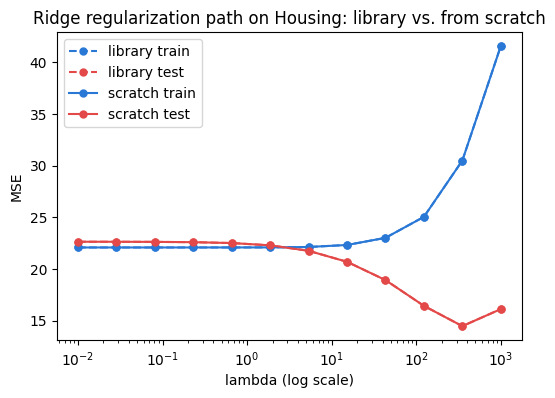

In [57]:
lambdas = np.logspace(-2, 3, 12)

lib_ridge_train, lib_ridge_test = [], []
scratch_ridge_train, scratch_ridge_test = [], []
for lmbda in lambdas:
    sk_r = SkRidge(alpha=lmbda).fit(X_train_housing, y_train_housing)
    lib_ridge_train.append(mse_loss(y_train_housing, sk_r.predict(X_train_housing)))
    lib_ridge_test.append(mse_loss(y_test_housing, sk_r.predict(X_test_housing)))

    r = RidgeRegressor(lmbda=lmbda)
    r.fit(X_train_housing, y_train_housing)
    scratch_ridge_train.append(mse_loss(y_train_housing, r.predict(X_train_housing)))
    scratch_ridge_test.append(mse_loss(y_test_housing, r.predict(X_test_housing)))

plt.figure(figsize=(6, 4))
plt.plot(lambdas, lib_ridge_train, color="#2a78d6", linestyle="--", marker="o", markersize=5, label="library train")
plt.plot(lambdas, lib_ridge_test, color="#e34948", linestyle="--", marker="o", markersize=5, label="library test")
plt.plot(lambdas, scratch_ridge_train, color="#2a78d6", linestyle="-", marker="o", markersize=5, label="scratch train")
plt.plot(lambdas, scratch_ridge_test, color="#e34948", linestyle="-", marker="o", markersize=5, label="scratch test")
plt.xscale("log")
plt.xlabel("lambda (log scale)")
plt.ylabel("MSE")
plt.title("Ridge regularization path on Housing: library vs. from scratch")
plt.legend()
plt.show()


---
## Problem 2 — Decision / Regression Tree from scratch

### (a) Library baseline: `sklearn.tree.DecisionTreeClassifier` / `DecisionTreeRegressor`

Same split criteria (`entropy` for Spambase, `squared_error`/variance for Housing) and the same
depth sweep, so the train/test numbers can be read side by side with the from-scratch tree.


In [58]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

depths = [2, 4, 6, 8]
lib_tree_spam_train, lib_tree_spam_test = [], []
for depth in depths:
    clf = DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=0)
    clf.fit(X_train_spam, y_train_spam)  ### fit sklearn's DecisionTreeClassifier(criterion='entropy') as the library baseline
    acc_train = accuracy_score(y_train_spam, clf.predict(X_train_spam))
    acc_test = accuracy_score(y_test_spam, clf.predict(X_test_spam))
    lib_tree_spam_train.append(acc_train)
    lib_tree_spam_test.append(acc_test)
    print(f"[library] Spambase tree depth={depth}: train acc = {acc_train:.3f}, test acc = {acc_test:.3f}")


[library] Spambase tree depth=2: train acc = 0.868, test acc = 0.849
[library] Spambase tree depth=4: train acc = 0.912, test acc = 0.885
[library] Spambase tree depth=6: train acc = 0.932, test acc = 0.902
[library] Spambase tree depth=8: train acc = 0.952, test acc = 0.907


In [59]:
lib_tree_house_train, lib_tree_house_test = [], []
for depth in depths:
    reg = DecisionTreeRegressor(criterion="squared_error", max_depth=depth, random_state=0)
    reg.fit(X_train_housing, y_train_housing)  ### TODO_STUDENT ### fit sklearn's DecisionTreeRegressor(criterion='squared_error') as the library baseline
    mse_train = mse_loss(y_train_housing, reg.predict(X_train_housing))
    mse_test = mse_loss(y_test_housing, reg.predict(X_test_housing))
    lib_tree_house_train.append(mse_train)
    lib_tree_house_test.append(mse_test)
    print(f"[library] Housing tree depth={depth}: train MSE = {mse_train:.3f}, test MSE = {mse_test:.3f}")


[library] Housing tree depth=2: train MSE = 26.497, test MSE = 24.282
[library] Housing tree depth=4: train MSE = 9.002, test MSE = 50.084
[library] Housing tree depth=6: train MSE = 4.913, test MSE = 52.562
[library] Housing tree depth=8: train MSE = 2.239, test MSE = 48.308


### (b) From scratch: entropy / variance-reduction tree

A single tree class handles both cases: **entropy / information gain** for classification
(Spambase), **variance / MSE reduction** for regression (Housing). Since features are
continuous, candidate splits are the midpoints between consecutive sorted unique values of a
feature (this is the standard trick — it's exactly the threshold that could possibly separate
two adjacent points, so we never need to check more than that).

This tree is written as a reusable module (`fit`/`predict`): HW2's gradient-boosting problem and
HW1 Problem 3 below both reuse it as the weak learner.


In [60]:
def entropy(y):
    _, counts = np.unique(y, return_counts=True)
    p = counts / len(y)
    return -np.sum(p * np.log2(p))  ### implement the Shannon entropy formula, -sum(p * log2(p))


def variance(y):
    if len(y) == 0:
        return 0.0
    return np.var(y)  ### implement the variance (mean squared deviation from the mean) formula


def candidate_thresholds(column):
    """Midpoints between consecutive sorted unique values -- the only splits that can matter."""
    values = np.unique(column)
    return (values[:-1] + values[1:]) / 2  ### compute the midpoints between consecutive sorted unique values as candidate split thresholds


class TreeNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value  # only set on leaves

    def is_leaf(self):
        return self.value is not None


In [61]:
class DecisionTree:
    """Binary decision/regression tree with threshold splits on numeric features.

    mode='classification' splits on information gain (entropy) and leaves store the
    majority class; mode='regression' splits on variance reduction and leaves store the mean.
    """

    def __init__(self, mode="classification", max_depth=5, min_samples_split=2):
        assert mode in ("classification", "regression")
        self.mode = mode
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.impurity = entropy if self.mode == "classification" else variance  ### pick the impurity function for this tree: entropy for classification splits, variance for regression splits

    def fit(self, X, y):
        self.root = self._grow(X, y, depth=0)
        return self

    def _leaf_value(self, y):
        if self.mode == "classification":
            values, counts = np.unique(y, return_counts=True)
            return values[np.argmax(counts)]  ### return the majority class label among this leaf's points
        return np.mean(y)  ### return the mean target value among this leaf's points

    def _grow(self, X, y, depth):
        n, m = X.shape

        # stopping conditions: max depth reached, pure node, or too few points to split
        if depth >= self.max_depth or len(np.unique(y)) == 1 or len(y) < self.min_samples_split:  ### decide when to stop splitting and turn this node into a leaf
            return TreeNode(value=self._leaf_value(y))

        parent_impurity = self.impurity(y)
        best_gain, best_feature, best_threshold = 0.0, None, None

        for feature in range(m):
            for threshold in candidate_thresholds(X[:, feature]):
                left_mask = X[:, feature] <= threshold   ### define which points fall left vs. right of this candidate threshold
                right_mask = ~left_mask
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:  ### skip candidate thresholds that would leave one side empty
                    continue

                y_left, y_right = y[left_mask], y[right_mask]
                weighted_child_impurity = (np.sum(left_mask) / len(y)) * self.impurity(y_left) + (np.sum(right_mask) / len(y)) * self.impurity(y_right)  ### weight each child's impurity by the fraction of the parent's points it received
                gain = parent_impurity - weighted_child_impurity  ### compute the information/variance gain of this candidate split (parent impurity minus weighted child impurity)

                if gain > best_gain:
                    best_gain, best_feature, best_threshold = gain, feature, threshold   ### keep track of the best (feature, threshold) split seen so far

        # no split improves things -> make a leaf
        if best_feature is None:
            return TreeNode(value=self._leaf_value(y))

        left_mask = X[:, best_feature] <= best_threshold  ### recompute the partition using the winning (best_feature, best_threshold) before recursing
        right_mask = ~left_mask
        left = self._grow(X[left_mask], y[left_mask], depth + 1)  ### recursively grow the left subtree on the left split
        right = self._grow(X[right_mask], y[right_mask], depth + 1)  ### recursively grow the right subtree on the right split
        return TreeNode(feature=best_feature, threshold=best_threshold, left=left, right=right)

    def _predict_one(self, x, node):
        if node.is_leaf():
            return node.value
        branch = node.left if x[node.feature] <= node.threshold else node.right  ### walk left or right at this node based on the split threshold
        return self._predict_one(x, branch)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])


In [62]:
# Spambase: classification tree (information gain), a few depths to see over/under-fitting
scratch_tree_spam_train, scratch_tree_spam_test = [], []
for depth in depths:
    tree = DecisionTree(mode="classification", max_depth=depth).fit(X_train_spam, y_train_spam)
    acc_train = accuracy_score(y_train_spam, tree.predict(X_train_spam))
    acc_test = accuracy_score(y_test_spam, tree.predict(X_test_spam))
    scratch_tree_spam_train.append(acc_train)
    scratch_tree_spam_test.append(acc_test)
    print(f"[scratch] Spambase tree depth={depth}: train acc = {acc_train:.3f}, test acc = {acc_test:.3f}")


[scratch] Spambase tree depth=2: train acc = 0.868, test acc = 0.849
[scratch] Spambase tree depth=4: train acc = 0.912, test acc = 0.885
[scratch] Spambase tree depth=6: train acc = 0.932, test acc = 0.903
[scratch] Spambase tree depth=8: train acc = 0.953, test acc = 0.916


In [63]:
# Housing: regression tree (variance reduction), same depth sweep
scratch_tree_house_train, scratch_tree_house_test = [], []
for depth in depths:
    tree = DecisionTree(mode="regression", max_depth=depth).fit(X_train_housing, y_train_housing)
    mse_train = mse_loss(y_train_housing, tree.predict(X_train_housing))
    mse_test = mse_loss(y_test_housing, tree.predict(X_test_housing))
    scratch_tree_house_train.append(mse_train)
    scratch_tree_house_test.append(mse_test)
    print(f"[scratch] Housing tree depth={depth}: train MSE = {mse_train:.3f}, test MSE = {mse_test:.3f}")


[scratch] Housing tree depth=2: train MSE = 26.497, test MSE = 24.282
[scratch] Housing tree depth=4: train MSE = 9.002, test MSE = 35.779
[scratch] Housing tree depth=6: train MSE = 4.913, test MSE = 33.134
[scratch] Housing tree depth=8: train MSE = 2.239, test MSE = 34.324


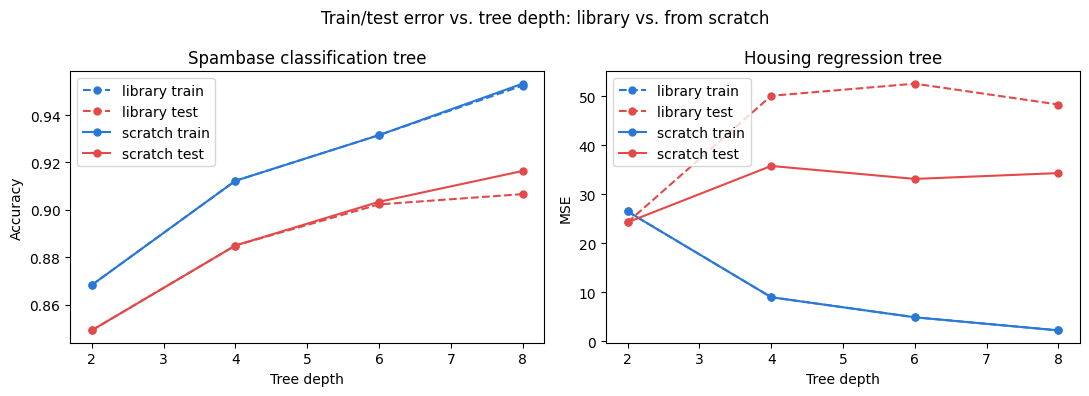

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(depths, lib_tree_spam_train, color="#2a78d6", linestyle="--", marker="o", markersize=5, label="library train")
axes[0].plot(depths, lib_tree_spam_test, color="#e34948", linestyle="--", marker="o", markersize=5, label="library test")
axes[0].plot(depths, scratch_tree_spam_train, color="#2a78d6", linestyle="-", marker="o", markersize=5, label="scratch train")
axes[0].plot(depths, scratch_tree_spam_test, color="#e34948", linestyle="-", marker="o", markersize=5, label="scratch test")
axes[0].set_xlabel("Tree depth")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Spambase classification tree")
axes[0].legend()

axes[1].plot(depths, lib_tree_house_train, color="#2a78d6", linestyle="--", marker="o", markersize=5, label="library train")
axes[1].plot(depths, lib_tree_house_test, color="#e34948", linestyle="--", marker="o", markersize=5, label="library test")
axes[1].plot(depths, scratch_tree_house_train, color="#2a78d6", linestyle="-", marker="o", markersize=5, label="scratch train")
axes[1].plot(depths, scratch_tree_house_test, color="#e34948", linestyle="-", marker="o", markersize=5, label="scratch test")
axes[1].set_xlabel("Tree depth")
axes[1].set_ylabel("MSE")
axes[1].set_title("Housing regression tree")
axes[1].legend()

fig.suptitle("Train/test error vs. tree depth: library vs. from scratch")
fig.tight_layout()
plt.show()


Both sweeps (library and from-scratch) should show the classic pattern: deeper trees keep improving train error while test error flattens out or gets worse. The right depth is the one where *test* performance stops improving (the bias-variance tradeoff), not the one where train and test happen to be numerically closest -- a very shallow, underfit tree can have a tiny train/test gap while both numbers are simply bad, which is not what we want. In practice you'd pick a final depth via a validation split or cross-validation, not by reading the test curve directly (that's tuning on the test set); the sweep here is a diagnostic showing you the tradeoff, not a tuning procedure. Check that your from-scratch numbers track the library ones closely at every depth on Spambase -- that's the sanity check to look for. On Housing, don't be surprised if the two start to diverge on *test* MSE at deeper depths (4+) even though both still look reasonable by *training* loss: with only 433 training rows and 13 correlated features, many splits tie or nearly tie on variance reduction, so `sklearn`'s tie-breaking and yours can legitimately pick different (but similarly good) trees deeper down. That would be expected small-sample variance, not a bug -- and it's itself a nice illustration of the instability of deep single trees, which Problem 3's boosting exists to tame.

---
## Problem 3 — Boosted Trees for Regression (Housing)

### (a) Library baseline: `sklearn.ensemble.GradientBoostingRegressor`

With `loss="squared_error"`, this *is* residual-fitting boosting (each new tree fits the
current residual). We set `learning_rate=1.0` to match our from-scratch version, which takes a
full step at each round rather than shrinking it.


In [65]:
from sklearn.ensemble import GradientBoostingRegressor

n_rounds = 60
sk_gbr = GradientBoostingRegressor(
    loss="squared_error", n_estimators=n_rounds, max_depth=2, learning_rate=1.0, random_state=0
).fit(X_train_housing, y_train_housing)   ### TODO_STUDENT ### fit sklearn's GradientBoostingRegressor(learning_rate=1.0) as the residual-boosting library baseline

lib_train_mses = [mse_loss(y_train_housing, pred) for pred in sk_gbr.staged_predict(X_train_housing)]
lib_test_mses = [mse_loss(y_test_housing, pred) for pred in sk_gbr.staged_predict(X_test_housing)]

print(f"[library] Final (T={n_rounds}): train MSE = {lib_train_mses[-1]:.3f}, test MSE = {lib_test_mses[-1]:.3f}")


[library] Final (T=60): train MSE = 0.926, test MSE = 25.927


### (b) From scratch: residual boosting with our own tree

Fit a sequence of shallow regression trees to the *residuals* of the running prediction (no
re-weighting of points, unlike AdaBoost). Each new tree nudges the ensemble's prediction a
little closer to the true labels. We reuse the `DecisionTree` class from Problem 2 (depth 2) as
the weak learner, exactly as the assignment asks.


In [66]:
class BoostedRegressionTrees:
    def __init__(self, n_rounds=100, tree_depth=2):
        self.n_rounds = n_rounds
        self.tree_depth = tree_depth

    def fit(self, X, y):
        self.trees = []
        residual = y.copy()
        for _ in range(self.n_rounds):
            tree = DecisionTree(mode="regression", max_depth=self.tree_depth)  ### fit a shallow regression tree to the current residuals
            tree.fit(X, residual)
            self.trees.append(tree)
            residual = residual - tree.predict(X)  ### update the residuals by subtracting this round's tree predictions
        return self

    def predict(self, X):
        return sum(tree.predict(X) for tree in self.trees)  ### TODO_STUDENT ### sum every tree's prediction to form the boosted ensemble output

    def staged_predict(self, X):
        """Yield the ensemble prediction after each additional tree (for the T-sweep plot)."""
        total = np.zeros(X.shape[0])
        for tree in self.trees:
            total = total + tree.predict(X)  ### TODO_STUDENT ### accumulate this round's tree prediction into the running ensemble total
            yield total


In [67]:
boosted = BoostedRegressionTrees(n_rounds=n_rounds, tree_depth=2).fit(X_train_housing, y_train_housing)

train_mses, test_mses = [], []
for train_pred, test_pred in zip(boosted.staged_predict(X_train_housing),
                                  boosted.staged_predict(X_test_housing)):
    train_mses.append(mse_loss(y_train_housing, train_pred))
    test_mses.append(mse_loss(y_test_housing, test_pred))

print(f"[scratch] Final (T={n_rounds}): train MSE = {train_mses[-1]:.3f}, test MSE = {test_mses[-1]:.3f}")


[scratch] Final (T=60): train MSE = 0.926, test MSE = 26.299


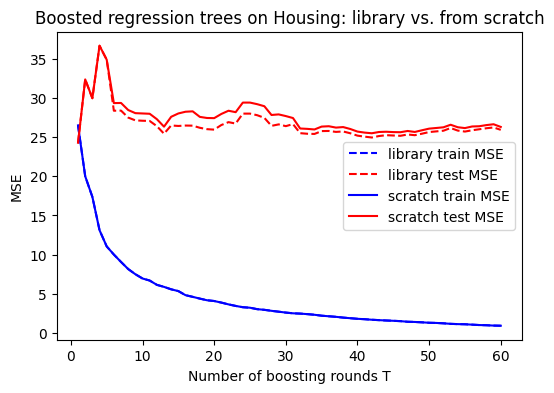

In [68]:
# Library vs. scratch, overlaid: both should tell the same overfitting story as T grows.
plt.figure(figsize=(6, 4))
rounds = range(1, n_rounds + 1)
plt.plot(rounds, lib_train_mses, "b--", label="library train MSE")
plt.plot(rounds, lib_test_mses, "r--", label="library test MSE")
plt.plot(rounds, train_mses, "b-", label="scratch train MSE")
plt.plot(rounds, test_mses, "r-", label="scratch test MSE")
plt.xlabel("Number of boosting rounds T")
plt.ylabel("MSE")
plt.title("Boosted regression trees on Housing: library vs. from scratch")
plt.legend()
plt.show()


---
## Problem 4 — Similarity & KNN from scratch

### (a) Library baseline: `sklearn.neighbors.KNeighborsClassifier` / `RadiusNeighborsClassifier`

`KNeighborsClassifier` supports `'euclidean'` and `'cosine'` directly. For the RBF and
degree-2-polynomial *kernel* similarities there's no ready-made "kernel-KNN" in sklearn, so we
precompute the kernel matrix with `sklearn.metrics.pairwise` (still 100% library code) and hand
it to `KNeighborsClassifier(metric="precomputed")` — the library still owns the neighbor search
and the majority vote, which is the part we're benchmarking.


In [69]:
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier

# (A) Fixed k -- Spambase with Euclidean distance
for k in [1, 3, 7]:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean').fit(X_train_spam, y_train_spam)  ### fit sklearn's KNeighborsClassifier with Euclidean distance as the library baseline
    acc_train = accuracy_score(y_train_spam, knn.predict(X_train_spam))
    acc_test = accuracy_score(y_test_spam, knn.predict(X_test_spam))
    print(f"[library] Spambase kNN (euclidean, k={k}): train acc = {acc_train:.3f}, test acc = {acc_test:.3f}")


[library] Spambase kNN (euclidean, k=1): train acc = 0.999, test acc = 0.894
[library] Spambase kNN (euclidean, k=3): train acc = 0.950, test acc = 0.891
[library] Spambase kNN (euclidean, k=7): train acc = 0.926, test acc = 0.895


In [70]:
# (A) Fixed k -- MNIST with cosine distance (native metric) and RBF / poly-2 kernels (precomputed)
for k in [1, 3, 7]:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine').fit(X_train_digits, y_train_digits)  ### fit sklearn's KNeighborsClassifier with cosine distance as the library baseline
    acc_train = accuracy_score(y_train_digits, knn.predict(X_train_digits))
    acc_test = accuracy_score(y_test_digits, knn.predict(X_test_digits))
    print(f"[library] MNIST kNN (cosine, k={k}): train acc = {acc_train:.3f}, test acc = {acc_test:.3f}")

kernel_specs = {
    "rbf": lambda A, B: rbf_kernel(A, B, gamma=1e-3),  ### TODO_STUDENT ### compute the RBF (Gaussian) kernel similarity matrix between two point sets
    "poly": lambda A, B: polynomial_kernel(A, B, degree=2, coef0=0),  ### TODO_STUDENT ### compute the degree-2 polynomial kernel similarity matrix between two point sets
}
for name, kernel_fn in kernel_specs.items():
    K_train = kernel_fn(X_train_digits, X_train_digits)
    K_test = kernel_fn(X_test_digits, X_train_digits)
    # sklearn's metric="precomputed" requires a non-negative *distance* matrix; "larger kernel
    # value = closer" flips to "smaller distance = closer" via this order-reversing shift
    shift = max(K_train.max(), K_test.max())  ### TODO_STUDENT ### pick one global shift so both kernel blocks convert to comparable non-negative distances
    D_train = shift - K_train
    D_test = shift - K_test
    for k in [1, 3, 7]:
        knn = KNeighborsClassifier(metric='precomputed', n_neighbors=k).fit(D_train, y_train_digits)  ### TODO_STUDENT ### fit sklearn's KNeighborsClassifier on the precomputed kernel-distance matrix
        acc_train = accuracy_score(y_train_digits, knn.predict(D_train))
        acc_test = accuracy_score(y_test_digits, knn.predict(D_test))
        print(f"[library] MNIST kNN ({name}, k={k}): train acc = {acc_train:.3f}, test acc = {acc_test:.3f}")


[library] MNIST kNN (cosine, k=1): train acc = 1.000, test acc = 0.899
[library] MNIST kNN (cosine, k=3): train acc = 0.955, test acc = 0.909
[library] MNIST kNN (cosine, k=7): train acc = 0.929, test acc = 0.908
[library] MNIST kNN (rbf, k=1): train acc = 1.000, test acc = 0.893
[library] MNIST kNN (rbf, k=3): train acc = 0.954, test acc = 0.899
[library] MNIST kNN (rbf, k=7): train acc = 0.926, test acc = 0.907
[library] MNIST kNN (poly, k=1): train acc = 0.503, test acc = 0.482
[library] MNIST kNN (poly, k=3): train acc = 0.567, test acc = 0.580
[library] MNIST kNN (poly, k=7): train acc = 0.536, test acc = 0.521


In [71]:
# (B) Fixed window -- Spambase with Euclidean distance
# most_frequent fallback for points with an empty radius, matching the spirit of our
# from-scratch fallback below (predict *something* rather than erroring out)
spam_radii = [4.0, 6.0, 8.0, 10.0]
lib_window_spam_train, lib_window_spam_test = [], []
for r in spam_radii:
    rnn = RadiusNeighborsClassifier(radius=r, metric="euclidean", outlier_label="most_frequent")
    rnn.fit(X_train_spam, y_train_spam)  ### fit sklearn's RadiusNeighborsClassifier as the library baseline for the fixed-window classifier on Spambase
    acc_train = accuracy_score(y_train_spam, rnn.predict(X_train_spam))
    acc_test = accuracy_score(y_test_spam, rnn.predict(X_test_spam))
    lib_window_spam_train.append(acc_train)
    lib_window_spam_test.append(acc_test)
    print(f"[library] Spambase window (euclidean, r={r}): train acc = {acc_train:.3f}, test acc = {acc_test:.3f}")


[library] Spambase window (euclidean, r=4.0): train acc = 0.876, test acc = 0.817
[library] Spambase window (euclidean, r=6.0): train acc = 0.776, test acc = 0.739
[library] Spambase window (euclidean, r=8.0): train acc = 0.703, test acc = 0.685
[library] Spambase window (euclidean, r=10.0): train acc = 0.658, test acc = 0.626


In [72]:
# (B) Fixed window -- MNIST with cosine distance
digits_radii = [0.05, 0.1, 0.15, 0.2]
lib_window_digits_train, lib_window_digits_test = [], []
for r in digits_radii:
    rnn = RadiusNeighborsClassifier(radius=r, metric="cosine", algorithm="brute", outlier_label="most_frequent")
    rnn.fit(X_train_digits, y_train_digits)  ### fit sklearn's RadiusNeighborsClassifier as the library baseline for the fixed-window classifier on MNIST
    acc_train = accuracy_score(y_train_digits, rnn.predict(X_train_digits))
    acc_test = accuracy_score(y_test_digits, rnn.predict(X_test_digits))
    lib_window_digits_train.append(acc_train)
    lib_window_digits_test.append(acc_test)
    print(f"[library] MNIST window (cosine, r={r}): train acc = {acc_train:.3f}, test acc = {acc_test:.3f}")


[library] MNIST window (cosine, r=0.05): train acc = 0.970, test acc = 0.585
[library] MNIST window (cosine, r=0.1): train acc = 0.888, test acc = 0.817
[library] MNIST window (cosine, r=0.15): train acc = 0.810, test acc = 0.802
[library] MNIST window (cosine, r=0.2): train acc = 0.735, test acc = 0.749


At the tightest radius (`r=0.05`), expect a meaningful fraction of the 1000 MNIST test points to have *zero* training points within range (cosine distance is a tight metric on 200-d Haar features). The library's `outlier_label="most_frequent"` dumps every one of those into the single most common training digit -- watch what that does to test accuracy at this radius. Our from-scratch fallback below instead backs off to the single nearest point for those cases, which should be a much better rule for a well-separated multiclass problem: look for a noticeably higher test accuracy than the library's fallback at this same tight radius, with the gap closing up as the radius grows and empty neighborhoods become rare.

### (b) From scratch: KNN and fixed-window classifiers

No training phase: at query time we compute the distance/similarity from each test point to
every training point, then either take a **majority vote over the k nearest** (part A) or a
**majority vote over everyone inside a fixed radius/window** (part B).


In [73]:
class KNNClassifier:
    """k-NN (or fixed-window) classifier with a choice of distance/similarity function.

    If `radius` is set, `k` is ignored: every training point within `radius` votes.
    `metric` is one of {'euclidean', 'cosine', 'rbf', 'poly'} (the last two are kernel
    similarities, so larger = closer -- we negate them to reuse the same "smallest distance
    wins" logic).
    """

    def __init__(self, k=1, radius=None, metric="euclidean", gamma=1.0, degree=2, coef0=0.0):
        self.k = k
        self.radius = radius
        self.metric = metric
        self.gamma = gamma
        self.degree = degree
        self.coef0 = coef0

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        return self

    def _distances(self, X_test):
        if self.metric == "euclidean":
            return pairwise_distances(X_test, self.X_train, metric="euclidean")  ### compute the Euclidean distance from every test point to every training point
        if self.metric == "cosine":
            return pairwise_distances(X_test, self.X_train, metric="cosine")   ### compute the cosine distance from every test point to every training point
        if self.metric == "rbf":
            return -rbf_kernel(X_test, self.X_train, gamma=self.gamma)  ### compute the (negated) RBF kernel similarity as a distance surrogate
        if self.metric == "poly":
            return -polynomial_kernel(X_test, self.X_train, degree=self.degree, coef0=self.coef0)   ### compute the (negated) degree-d polynomial kernel similarity as a distance surrogate
        raise ValueError(f"unknown metric {self.metric}")

    def _vote(self, neighbor_labels):
        values, counts = np.unique(neighbor_labels, return_counts=True)
        return values[np.argmax(counts)]  ### return the majority label among the neighbor votes

    def predict(self, X_test):
        D = self._distances(X_test)
        predictions = np.empty(X_test.shape[0], dtype=self.y_train.dtype)

        for i in range(X_test.shape[0]):
            row = D[i]
            if self.radius is None:
                nearest = np.argsort(row)[:self.k]  ### select the indices of the k nearest training points
            else:
                nearest = np.where(row <= self.radius)[0]  ### select the indices of every training point within the fixed radius
                if len(nearest) == 0:
                    # nothing in the window: fall back to the single nearest point
                    nearest = np.argsort(row)[:1]  ### when nothing falls inside the radius, back off to the single nearest point rather than refusing to predict
            predictions[i] = self._vote(self.y_train[nearest])

        return predictions


In [74]:
# (A) Fixed k -- Spambase with Euclidean distance
for k in [1, 3, 7]:
    knn = KNNClassifier(k=k, metric="euclidean").fit(X_train_spam, y_train_spam)
    acc_train = accuracy_score(y_train_spam, knn.predict(X_train_spam))
    acc_test = accuracy_score(y_test_spam, knn.predict(X_test_spam))
    print(f"[scratch] Spambase kNN (euclidean, k={k}): train acc = {acc_train:.3f}, test acc = {acc_test:.3f}")


[scratch] Spambase kNN (euclidean, k=1): train acc = 1.000, test acc = 0.894
[scratch] Spambase kNN (euclidean, k=3): train acc = 0.950, test acc = 0.891
[scratch] Spambase kNN (euclidean, k=7): train acc = 0.926, test acc = 0.895


In [75]:
# (A) Fixed k -- MNIST with cosine distance, Gaussian (RBF) kernel, degree-2 polynomial kernel
k_values = [1, 3, 7]
digits_knn_by_metric = {}
for metric, kwargs in [("cosine", {}), ("rbf", {"gamma": 1e-3}), ("poly", {"degree": 2, "gamma": 1e-3})]:
    train_accs, test_accs = [], []
    for k in k_values:
        knn = KNNClassifier(k=k, metric=metric, **kwargs).fit(X_train_digits, y_train_digits)
        acc_train = accuracy_score(y_train_digits, knn.predict(X_train_digits))
        acc_test = accuracy_score(y_test_digits, knn.predict(X_test_digits))
        train_accs.append(acc_train)
        test_accs.append(acc_test)
        print(f"[scratch] MNIST kNN ({metric}, k={k}): train acc = {acc_train:.3f}, test acc = {acc_test:.3f}")
    digits_knn_by_metric[metric] = (train_accs, test_accs)


[scratch] MNIST kNN (cosine, k=1): train acc = 1.000, test acc = 0.899
[scratch] MNIST kNN (cosine, k=3): train acc = 0.955, test acc = 0.909
[scratch] MNIST kNN (cosine, k=7): train acc = 0.929, test acc = 0.908
[scratch] MNIST kNN (rbf, k=1): train acc = 1.000, test acc = 0.893
[scratch] MNIST kNN (rbf, k=3): train acc = 0.954, test acc = 0.899
[scratch] MNIST kNN (rbf, k=7): train acc = 0.926, test acc = 0.907
[scratch] MNIST kNN (poly, k=1): train acc = 0.503, test acc = 0.482
[scratch] MNIST kNN (poly, k=3): train acc = 0.567, test acc = 0.580
[scratch] MNIST kNN (poly, k=7): train acc = 0.536, test acc = 0.521


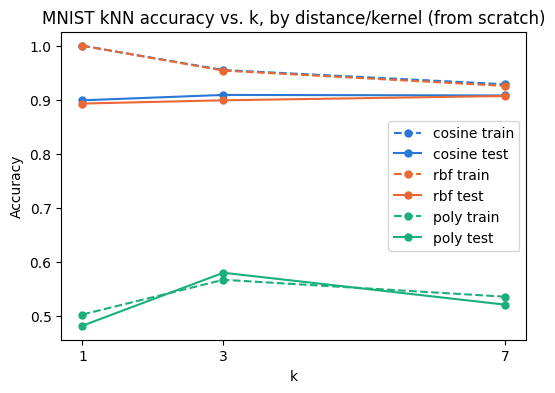

In [76]:
metric_colors = {"cosine": "#2a78d6", "rbf": "#eb6834", "poly": "#1baf7a"}

plt.figure(figsize=(6, 4))
for metric, (train_accs, test_accs) in digits_knn_by_metric.items():
    color = metric_colors[metric]
    plt.plot(k_values, train_accs, color=color, linestyle="--", marker="o", markersize=5, label=f"{metric} train")
    plt.plot(k_values, test_accs, color=color, linestyle="-", marker="o", markersize=5, label=f"{metric} test")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("MNIST kNN accuracy vs. k, by distance/kernel (from scratch)")
plt.xticks(k_values)
plt.legend()
plt.show()


Expect cosine and RBF to land well above the degree-2 polynomial kernel here (matching the library numbers above) -- and if the polynomial kernel looks surprisingly weak in both the library and scratch versions, that's not necessarily a bug, it may be the kernel: both use `coef0=0` (a *homogeneous* poly kernel), and for `coef0=0` with any positive `gamma`, rescaling `gamma` only rescales every entry by the same monotone function, so it can never change the neighbor *ranking*. (This is specific to `coef0=0` -- an *inhomogeneous* kernel, `coef0>0`, does not have this invariance, since adding a constant before raising to a power is not a monotone rescaling of the dot product.) If your numbers come out this way, it's worth reporting as a real finding about this kernel/feature combination, not something to tune away.

In [77]:
# (B) Fixed window -- Spambase with Euclidean distance
scratch_window_spam_train, scratch_window_spam_test = [], []
for r in spam_radii:
    knn = KNNClassifier(radius=r, metric="euclidean").fit(X_train_spam, y_train_spam)
    acc_train = accuracy_score(y_train_spam, knn.predict(X_train_spam))
    acc_test = accuracy_score(y_test_spam, knn.predict(X_test_spam))
    scratch_window_spam_train.append(acc_train)
    scratch_window_spam_test.append(acc_test)
    print(f"[scratch] Spambase window (euclidean, r={r}): train acc = {acc_train:.3f}, test acc = {acc_test:.3f}")


[scratch] Spambase window (euclidean, r=4.0): train acc = 0.876, test acc = 0.847
[scratch] Spambase window (euclidean, r=6.0): train acc = 0.776, test acc = 0.756
[scratch] Spambase window (euclidean, r=8.0): train acc = 0.703, test acc = 0.689
[scratch] Spambase window (euclidean, r=10.0): train acc = 0.658, test acc = 0.629


In [78]:
# (B) Fixed window -- MNIST with cosine distance
scratch_window_digits_train, scratch_window_digits_test = [], []
for r in digits_radii:
    knn = KNNClassifier(radius=r, metric="cosine").fit(X_train_digits, y_train_digits)
    acc_train = accuracy_score(y_train_digits, knn.predict(X_train_digits))
    acc_test = accuracy_score(y_test_digits, knn.predict(X_test_digits))
    scratch_window_digits_train.append(acc_train)
    scratch_window_digits_test.append(acc_test)
    print(f"[scratch] MNIST window (cosine, r={r}): train acc = {acc_train:.3f}, test acc = {acc_test:.3f}")


[scratch] MNIST window (cosine, r=0.05): train acc = 0.970, test acc = 0.902
[scratch] MNIST window (cosine, r=0.1): train acc = 0.888, test acc = 0.879
[scratch] MNIST window (cosine, r=0.15): train acc = 0.810, test acc = 0.816
[scratch] MNIST window (cosine, r=0.2): train acc = 0.735, test acc = 0.751


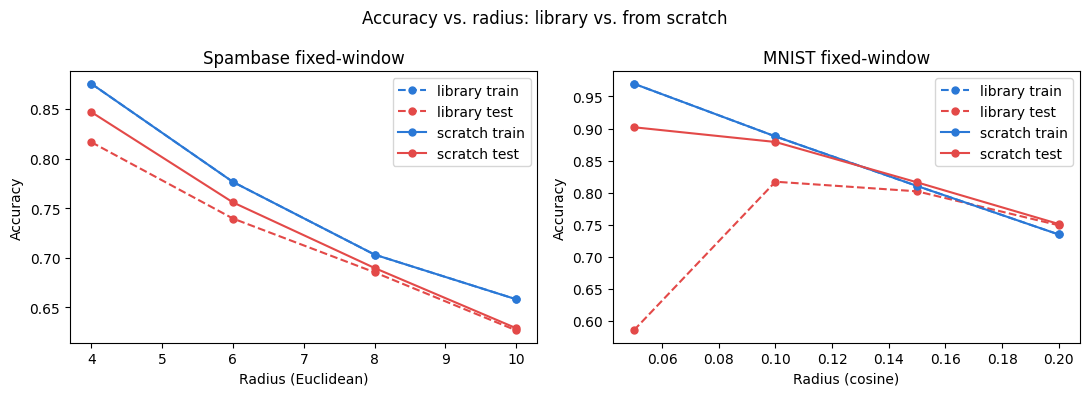

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(spam_radii, lib_window_spam_train, color="#2a78d6", linestyle="--", marker="o", markersize=5, label="library train")
axes[0].plot(spam_radii, lib_window_spam_test, color="#e34948", linestyle="--", marker="o", markersize=5, label="library test")
axes[0].plot(spam_radii, scratch_window_spam_train, color="#2a78d6", linestyle="-", marker="o", markersize=5, label="scratch train")
axes[0].plot(spam_radii, scratch_window_spam_test, color="#e34948", linestyle="-", marker="o", markersize=5, label="scratch test")
axes[0].set_xlabel("Radius (Euclidean)")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Spambase fixed-window")
axes[0].legend()

axes[1].plot(digits_radii, lib_window_digits_train, color="#2a78d6", linestyle="--", marker="o", markersize=5, label="library train")
axes[1].plot(digits_radii, lib_window_digits_test, color="#e34948", linestyle="--", marker="o", markersize=5, label="library test")
axes[1].plot(digits_radii, scratch_window_digits_train, color="#2a78d6", linestyle="-", marker="o", markersize=5, label="scratch train")
axes[1].plot(digits_radii, scratch_window_digits_test, color="#e34948", linestyle="-", marker="o", markersize=5, label="scratch test")
axes[1].set_xlabel("Radius (cosine)")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("MNIST fixed-window")
axes[1].legend()

fig.suptitle("Accuracy vs. radius: library vs. from scratch")
fig.tight_layout()
plt.show()


### (C) Kernel density estimation [optional, no credit]

Fit a per-class kernel density $P(z \mid C)$ using only that class's training points, then classify by $P(C \mid z) \propto P(C) \cdot P(z \mid C)$.

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KernelDensity

# library baseline: per-class sklearn KernelDensity, combined with class priors by hand
# (this *is* what GaussianNB does, except with a parametric Gaussian instead of a KDE --
# included here too since it's the library's closest ready-made "generative density" classifier)
gnb = GaussianNB...  ### TODO_STUDENT ### fit sklearn's GaussianNB as a reference parametric-density classifier
acc_train = accuracy_score(y_train_spam, gnb.predict(X_train_spam))
acc_test = accuracy_score(y_test_spam, gnb.predict(X_test_spam))
print(f"[library] Spambase GaussianNB (parametric density, for reference): train acc = {acc_train:.3f}, test acc = {acc_test:.3f}")

bandwidth = np....  ### TODO_STUDENT ### convert the RBF kernel's gamma into the equivalent Gaussian bandwidth, so this library KDE matches our scratch kernel
classes = np.unique(y_train_spam)
class_kdes = {c: KernelDensity...  ### TODO_STUDENT ### fit one sklearn KernelDensity estimator per class on that class's training points
              for c in classes}
priors = {c: np.mean(y_train_spam == c) for c in classes}

def kde_predict(X):
    log_scores = np.zeros((X.shape[0], len(classes)))
    for j, c in enumerate(classes):
        log_scores[:, j] = np....  ### TODO_STUDENT ### combine the class prior and the per-class KDE log-density into a log-posterior score
    return ...  ### TODO_STUDENT ### predict the class with the highest posterior score

acc_train = accuracy_score(y_train_spam, kde_predict(X_train_spam))
acc_test = accuracy_score(y_test_spam, kde_predict(X_test_spam))
print(f"[library] Spambase KernelDensity (Gaussian kernel): train acc = {acc_train:.3f}, test acc = {acc_test:.3f}")


In [ ]:
class KDEClassifier:
    """Naive-Bayes-style classifier: per-class kernel density estimate, Gaussian kernel."""

    def __init__(self, gamma=1.0):
        self.gamma = gamma

    def fit(self, X, y):
        self.classes = np.unique(y)
        self.class_data = ...  ### TODO_STUDENT ### partition the training data by class, so each class's density estimate only sees its own points
        self.priors = ...  ### TODO_STUDENT ### estimate each class's prior P(C) as its frequency in the training data
        return self

    def predict(self, X_test):
        log_scores = np.zeros((X_test.shape[0], len(self.classes)))
        for j, c in enumerate(self.classes):
            # average Gaussian-kernel similarity to this class's training points == density estimate
            density = ...  ### TODO_STUDENT ### estimate the class-conditional density as the average Gaussian-kernel similarity to that class's training points
            log_scores[:, j] = np....  ### TODO_STUDENT ### combine the class prior and the estimated density into a log-posterior score
        return ...  ### TODO_STUDENT ### predict the class with the highest posterior score


In [ ]:
kde = KDEClassifier(gamma=1e-3).fit(X_train_spam, y_train_spam)
acc_train = accuracy_score(y_train_spam, kde.predict(X_train_spam))
acc_test = accuracy_score(y_test_spam, kde.predict(X_test_spam))
print(f"[scratch] Spambase KDE (Gaussian kernel): train acc = {acc_train:.3f}, test acc = {acc_test:.3f}")


## Theory Question 5: Feature Importance Stability

A single decision tree makes one strict choice at every node, it picks whichever feature gives the biggest drop in impurity, even if another feature was almost as good. If we remove 10% of the training data, a close contest between two features (say A and B) can easily flip which one wins. Since the winning feature decides how the data splits into two groups, one flipped choice near the top of the tree changes what data reaches every node below it. This creates a chain reaction and the whole tree ends up structured differently, so the "important" features look different too, even though the tree's overall accuracy barely changes.

A boosted ensemble avoids this problem because the same task is spread across many (say, 60) small, shallow trees, and each tree corrects the mistakes left over from the ones before it. A feature's total importance is the sum of its impact across all 60 trees, not the result of one tree's structure. So if removing 10% of the data flips feature A vs. B's win in a handful of trees, it only shifts a small amount of importance between two similarly good features in those few trees and the total sum across all 60 trees barely moves. This is why averaging over many small models tends to give more stable, reliable results than relying on one big model.



## Theory Question 6: Fixed-k vs. Fixed-Window KNN Under Non-Uniform Density

I would use fixed-k as the default. The reason is that fixed-window's failure is much harder to work around in a sparse region, it can end up with zero neighbors and simply cannot make a prediction at all, unless you patch in a special case for that situation. Fixed-k never has this problem, since it always finds exactly k neighbors no matter how spread out the data is, so it always produces some kind of answer. Its weakness is that the neighbors it finds in sparse areas might be far away and not truly similar to the query point, is a milder problem because the model still gives a usable prediction, even if that prediction is less trustworthy in those regions.

To fix fixed-window's specific failure, one concrete change is to make the radius adaptive instead of fixed, based on local density. For example, at prediction time, first check how many training points fall within the original radius. If none are found, gradually expand the radius outward, in small steps, until at least one neighbor is found, then vote among whatever falls inside that expanded radius. This way, dense regions keep using their original tight radius (since it already finds neighbors there), while sparse regions automatically grow their radius until they can find a usable set of neighbors, avoiding the total prediction failure that a plain fixed radius would cause.

---
## Problem 5 (optional, substantial) — Second-order (Newton) Boosting, from the XGBoost paper

Problem 3's boosting fits trees to raw residuals -- a *first-order* method (it only uses the
gradient of the loss). XGBoost (Chen & Guestrin, 2016) generalizes this to a *second-order*
method: it also uses the loss's Hessian, which lets the regularized **structure score** decide
splits and gives a closed-form optimal weight for each leaf. We redo Problem 3's boosting as
**classification** on Spambase with log-loss, where the gradient/Hessian are no longer trivial
(unlike squared loss, where the Hessian is just 1).

### (a) Library baseline: `sklearn.ensemble.GradientBoostingClassifier`

`xgboost` itself isn't in the course environment, so we use sklearn's own gradient-boosted
classifier (`loss="log_loss"`) as the reference -- it isn't *exactly* the XGBoost algorithm (no
per-leaf L2 term, no explicit `gamma`), but it optimizes the same loss with the same "trees on
pseudo-residuals" family, so its train/test log-loss curve is the right shape to check ours
against.


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import log_loss

n_rounds5 = 60
sk_gbc = GradientBoostingClassifier(
    loss="log_loss", n_estimators=n_rounds5, max_depth=3, learning_rate=0.3, random_state=0
)...  ### TODO_STUDENT ### fit sklearn's GradientBoostingClassifier(loss='log_loss') as the library baseline

lib_train_logloss = [log_loss(y_train_spam, p[:, 1])
                      for p in sk_gbc.staged_predict_proba(X_train_spam)]
lib_test_logloss = [log_loss(y_test_spam, p[:, 1])
                     for p in sk_gbc.staged_predict_proba(X_test_spam)]

print(f"[library] Final (T={n_rounds5}): train log-loss = {lib_train_logloss[-1]:.3f}, "
      f"test log-loss = {lib_test_logloss[-1]:.3f}")


### (b) From scratch: gradients, Hessians, and the regularized structure score

For log-loss with prediction `p = sigmoid(F(x))` and label `y`, the per-point gradient and Hessian
(w.r.t. the raw score `F`, not `p`) are:

$$g_i = p_i - y_i \qquad h_i = p_i(1-p_i)$$

A candidate split on node data with gradient/Hessian sums `G, H` (and `G_L,H_L` / `G_R,H_R` for
the two children) is scored by the **structure score gain**:

$$\text{gain} = \frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{G^2}{H+\lambda} - \gamma$$

and a leaf's optimal weight, for fixed tree structure, is the closed form `w* = -G/(H+lambda)`.
`lambda` shrinks every leaf weight toward 0 (L2 regularization); `gamma` is a flat cost charged
per split, so a candidate split is only taken if it improves the score by more than `gamma`. We
reuse `candidate_thresholds` from Problem 2 for the split search.


In [ ]:
def sigmoid(z):
    return ...  ### TODO_STUDENT ### implement the sigmoid function that maps a raw score to a probability


class XGBoostStyleTree:
    """A regression tree whose splits are scored by the XGBoost structure score (gain), using
    per-point gradients/Hessians instead of variance or entropy."""

    def __init__(self, max_depth=3, min_samples_split=2, lmbda=1.0, gamma=0.0):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.lmbda = lmbda
        self.gamma = gamma

    def fit(self, X, g, h):
        self.root = self._grow(X, g, h, depth=0)
        return self

    def _leaf_weight(self, g, h):
        return ...  ### TODO_STUDENT ### compute the closed-form optimal leaf weight w* = -G/(H+lambda)

    def _grow(self, X, g, h, depth):
        n, m = X.shape
        G, H = g.sum(), h.sum()

        if ...:  ### TODO_STUDENT ### decide when to stop splitting and turn this node into a leaf
            return TreeNode(value=self._leaf_weight(g, h))

        parent_score = ...  ### TODO_STUDENT ### compute the parent node's structure score G^2/(H+lambda)
        best_gain, best_feature, best_threshold = 0.0, None, None

        for feature in range(m):
            for threshold in candidate_thresholds(X[:, feature]):
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask
                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                G_L, H_L = ...  ### TODO_STUDENT ### sum the gradients/Hessians of the points that would go left
                G_R, H_R = ...  ### TODO_STUDENT ### sum the gradients/Hessians of the points that would go right

                gain = ...  ### TODO_STUDENT ### compute the structure-score gain of this split, charging the flat cost gamma per split

                if gain > best_gain:
                    best_gain, best_feature, best_threshold = ...  ### TODO_STUDENT ### keep track of the best (feature, threshold) split seen so far

        if best_feature is None:
            return TreeNode(value=self._leaf_weight(g, h))

        left_mask = X[:, best_feature] <= best_threshold
        left = self._grow...  ### TODO_STUDENT ### recursively grow the left subtree on the left split's gradients/Hessians
        right = self._grow...  ### TODO_STUDENT ### recursively grow the right subtree on the right split's gradients/Hessians
        return TreeNode(feature=best_feature, threshold=best_threshold, left=left, right=right)

    def _predict_one(self, x, node):
        if node.is_leaf():
            return node.value
        branch = node.left if x[node.feature] <= node.threshold else node.right
        return self._predict_one(x, branch)

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])


In [ ]:
class SecondOrderBoostedClassifier:
    """Binary classification boosting on log-loss using XGBoost-style Newton steps: each round
    fits an XGBoostStyleTree to the current gradients/Hessians instead of raw residuals."""

    def __init__(self, n_rounds=60, tree_depth=3, learning_rate=0.3, lmbda=1.0, gamma=0.0):
        self.n_rounds = n_rounds
        self.tree_depth = tree_depth
        self.learning_rate = learning_rate
        self.lmbda = lmbda
        self.gamma = gamma

    def fit(self, X, y):
        self.trees = []
        F = np.zeros(X.shape[0])

        for _ in range(self.n_rounds):
            p = sigmoid(F)
            g = ...  ### TODO_STUDENT ### compute the log-loss gradient g_i = p_i - y_i
            h = ...  ### TODO_STUDENT ### compute the log-loss Hessian h_i = p_i(1-p_i)
            tree = XGBoostStyleTree(max_depth=self.tree_depth, lmbda=self.lmbda, gamma=self.gamma)
            tree.fit(X, g, h)
            self.trees.append(tree)
            F = ...  ### TODO_STUDENT ### take a Newton step: add this round's (learning-rate-scaled) tree output to the running score
        return self

    def staged_decision_function(self, X):
        F = np.zeros(X.shape[0])
        for tree in self.trees:
            F = ...  ### TODO_STUDENT ### accumulate this round's Newton step into the running score, for the staged log-loss curve
            yield F

    def predict_proba(self, X):
        F = np.zeros(X.shape[0])
        for tree in self.trees:
            F = F + self.learning_rate * tree.predict(X)
        return sigmoid(F)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


In [ ]:
second_order = SecondOrderBoostedClassifier(n_rounds=n_rounds5, tree_depth=3, learning_rate=0.3,
                                             lmbda=1.0, gamma=0.0).fit(X_train_spam, y_train_spam)

scratch_train_logloss = [log_loss(y_train_spam, sigmoid(F))
                          for F in second_order.staged_decision_function(X_train_spam)]
scratch_test_logloss = [log_loss(y_test_spam, sigmoid(F))
                         for F in second_order.staged_decision_function(X_test_spam)]

print(f"[scratch] Final (T={n_rounds5}): train log-loss = {scratch_train_logloss[-1]:.3f}, "
      f"test log-loss = {scratch_test_logloss[-1]:.3f}")


In [ ]:
plt.figure(figsize=(6, 4))
rounds5 = range(1, n_rounds5 + 1)
plt.plot(rounds5, lib_train_logloss, color="#2a78d6", linestyle="--", label="library train")
plt.plot(rounds5, lib_test_logloss, color="#e34948", linestyle="--", label="library test")
plt.plot(rounds5, scratch_train_logloss, color="#2a78d6", linestyle="-", label="scratch train")
plt.plot(rounds5, scratch_test_logloss, color="#e34948", linestyle="-", label="scratch test")
plt.xlabel("Number of boosting rounds T")
plt.ylabel("Log-loss")
plt.title("Second-order boosting on Spambase: library (first-order) vs. scratch (second-order)")
plt.legend()
plt.show()


Both curves should show the same overfitting shape (test log-loss bottoming out then creeping
back up) -- that's the sanity check to look for: your Newton-step trees are optimizing the same
loss the library's first-order boosting is, just with an extra (Hessian-aware) way of scoring
splits and weighting leaves, so the qualitative curve shape should match even though the two
methods differ.

### Reference notes for the no-LLM write-up (grading aid, not a student answer)

- **What second-order gets you over Problem 3:** Problem 3's boosting only knows the residual's
  *sign and size*; it can't tell "confidently wrong" from "barely wrong" the way a Hessian can.
  For log-loss, `h_i = p_i(1-p_i)` is largest when the model is most unsure (`p≈0.5`) and shrinks
  toward 0 as the model becomes confident -- so Newton steps are naturally smaller/more cautious
  exactly where the loss surface is curving fastest, which first-order gradient boosting can't see.
- **`g_i`, `h_i` for log-loss:** `g_i = p_i - y_i` (residual on the probability scale), `h_i =
  p_i(1-p_i)` (bounded in `[0, 0.25]`, i.e. a per-point "how flat is the loss here" curvature term).
- **Why `/(H+lambda)` regularizes:** it's a Newton step `-G/H` (like Newton's method for
  optimization) shrunk by adding `lambda` to the denominator -- exactly like ridge regression adds
  `lambda` to `XtX` before inverting. Small `H` (an uncertain/sparse leaf) gets shrunk hardest.
  - **Why `w*=-G/(H+lambda)` is optimal:** it's the minimizer of the node's *quadratic* (2nd-order
    Taylor) approximation to the loss plus an L2 penalty `0.5*lambda*w^2` on the leaf weight --
    literally solving `d/dw [G*w + 0.5*(H+lambda)*w^2] = 0`.
- **`lambda` vs `gamma`:** `lambda` regularizes *how big* a leaf's weight can be (shrinks toward
  0); `gamma` regularizes *how many* leaves you're allowed to have (a split must clear a minimum
  gain bar). Set both to 0 and this degenerates toward unregularized Newton boosting -- every split
  that helps even a hair gets taken, and leaf weights are unshrunk, so it overfits faster than
  Problem 3's boosting (which had no split criterion tunable at all beyond depth).
- **Where a real implementation typically first diverges from the library:** forgetting that `g`
  and `h` are derivatives *of the loss with respect to the raw score `F`*, not with respect to
  `p` -- plugging in `y - p` instead of `p - y` (sign flip) or using `1` instead of `p(1-p)` for the
  Hessian (i.e. accidentally reimplementing Problem 3's boosting) are the two most common bugs, and
  both show up as a *plausible-looking but wrong* log-loss curve rather than a crash.


### (c) Bonus: more than two classes (library only, MNIST)

Our from-scratch `XGBoostStyleTree`/`SecondOrderBoostedClassifier` assume binary log-loss.
Generalizing them to multiclass (softmax loss, a gradient/Hessian *per class*, one tree per class
per round) is a substantially bigger build and isn't required here -- we just check how the
*library* behaves with more than two classes, on a fresh MNIST split. (This split and model are
reused as-is in Problem 6's MNIST analysis.)


In [ ]:
# Fresh random 90/10 split, stratified per class (no folds), from a subsample of the pooled
# train+test Haar-feature arrays already loaded for Problem 4.
mnist_pool_X = np.vstack([X_train_digits_full, X_test_digits_full])
mnist_pool_y = np.concatenate([y_train_digits_full, y_test_digits_full])

rng_mnist = np.random.RandomState(2)
pool_idx = rng_mnist.choice(len(mnist_pool_X), size=4000, replace=False)
X_mnist, y_mnist = mnist_pool_X[pool_idx], mnist_pool_y[pool_idx]

X_train_mnist, X_test_mnist, y_train_mnist, y_test_mnist = train_test_split(
    X_mnist, y_mnist, test_size=0.10, stratify=y_mnist, random_state=2)
print("MNIST (fresh 90/10 split) train:", X_train_mnist.shape, " test:", X_test_mnist.shape)

n_rounds5_mnist = 60
sk_gbc_mnist = GradientBoostingClassifier(
    loss="log_loss", n_estimators=n_rounds5_mnist, max_depth=3, learning_rate=0.3, random_state=0
)...  ### TODO_STUDENT ### fit sklearn's multiclass GradientBoostingClassifier(loss='log_loss') on the MNIST split

mnist_train_logloss = [log_loss(y_train_mnist, p)
                        for p in sk_gbc_mnist.staged_predict_proba(X_train_mnist)]
mnist_test_logloss = [log_loss(y_test_mnist, p)
                       for p in sk_gbc_mnist.staged_predict_proba(X_test_mnist)]
acc_mnist = sk_gbc_mnist.score(X_test_mnist, y_test_mnist)

print(f"MNIST (10-class, library only): test accuracy = {acc_mnist:.3f}, "
      f"final train log-loss = {mnist_train_logloss[-1]:.3f}, "
      f"test log-loss = {mnist_test_logloss[-1]:.3f}")


In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, n_rounds5_mnist + 1), mnist_train_logloss, color="#2a78d6", label="train")
plt.plot(range(1, n_rounds5_mnist + 1), mnist_test_logloss, color="#e34948", label="test")
plt.xlabel("Number of boosting rounds T")
plt.ylabel("Log-loss")
plt.title("Multiclass gradient boosting on MNIST (library only, 10 classes)")
plt.legend()
plt.show()


With 10 classes instead of 2, expect log-loss to start much higher (guessing uniformly among 10
classes costs `ln(10) ≈ 2.30` nats vs. `ln(2) ≈ 0.69` for binary) -- but the overall *shape* of
the curve (a fast initial drop, then a slow climb back up as it overfits) should tell the same
qualitative story as Spambase. The multiclass case just fits *K* trees per round internally (one
per class) instead of one, which is exactly the generalization our from-scratch second-order tree
would need to support this properly.


---
## Problem 6 (optional) — Does boosting confidence track KNN neighborhood consistency?

**Hypothesis.** Shallow trees split the same feature space k-NN measures proximity in, so a test
point sitting in a locally *pure/consistent* neighborhood should tend to land on the "easy" side
of most trees in a boosted ensemble -- their contributions reinforce rather than cancel, giving a
large-magnitude, confident prediction. In a mixed/sparse neighborhood, different trees disagree,
partially cancel, and the ensemble's output stays close to "unsure."

We test this on **three** datasets, reusing already-fitted models and the same
`pairwise_distances` machinery from Problems 3/4/5 throughout -- no new data, and (for Spambase and
Housing) essentially no new training:

- **Spambase (classification):** confidence = boosting margin `|p(z) - 0.5| * 2` from the already
  -fit `second_order` classifier (Problem 5) -- zero retraining. Neighborhood consistency = k-NN
  **purity** (majority-class fraction among the k nearest Spambase training points), reusing the
  exact `pairwise_distances` call from Problem 4.
- **Housing (regression):** there's no "decision boundary" to be far from, so a large prediction
  doesn't mean "confident" -- it just means "predicted to be big." The regression-appropriate
  notion of confidence is *predictive uncertainty*: we bootstrap-resample the training set, refit
  Problem 3's `BoostedRegressionTrees` a handful of times, and use the **std of predictions across
  resamples** as an uncertainty score. Neighborhood consistency = k-NN **target spread** (std of y
  among the k nearest Housing training points) -- the direct regression analog of "purity."
- **MNIST (10-class classification):** reuses the fresh, class-stratified 90/10 split (no folds)
  and the library `sk_gbc_mnist` classifier from Problem 5's bonus section -- no new training here
  either. Confidence generalizes the Spambase margin to multiclass: `p_top1(z) - p_top2(z)`, the
  gap between the top two predicted-class probabilities (this collapses to exactly `|p-0.5|*2` in
  the binary case, so it's the same quantity, not an analogy). `knn_purity` is already
  class-count-generic, so it needs no change.

All three pairs are framed the same direction (confidence-vs-confidence for Spambase/MNIST,
uncertainty-vs-uncertainty for Housing) so a *positive* correlation is the predicted sign in every
case.


In [ ]:
from scipy.stats import pearsonr, spearmanr

def knn_purity(D, y_train, k):
    """Majority-class fraction among the k nearest neighbors, for each query row of D."""
    purities = np.empty(D.shape[0])
    for i in range(D.shape[0]):
        nearest = np.argsort(D[i])[:k]
        _, counts = np.unique(y_train[nearest], return_counts=True)
        purities[i] = ...  ### TODO_STUDENT ### compute the majority-class fraction among these k neighbors (the purity score)
    return purities


def knn_target_spread(D, y_train, k):
    """Std of the target value among the k nearest neighbors, for each query row of D."""
    spreads = np.empty(D.shape[0])
    for i in range(D.shape[0]):
        nearest = np.argsort(D[i])[:k]
        spreads[i] = ...  ### TODO_STUDENT ### compute the std of the target among these k neighbors (the spread score)
    return spreads


In [ ]:
# ---- Spambase: boosting margin vs. k-NN purity ----
D_spam_test_train = pairwise_distances(X_test_spam, X_train_spam, metric="euclidean")
margin_spam = np....  ### TODO_STUDENT ### define the boosting confidence score as the margin |p-0.5| rescaled to [0,1]

print("Spambase: margin vs. k-NN purity, at a few k")
for k in [5, 15, 31]:
    purity_spam_k = knn_purity(D_spam_test_train, y_train_spam, k)
    r_p, _ = pearsonr(margin_spam, purity_spam_k)
    r_s, _ = spearmanr(margin_spam, purity_spam_k)
    print(f"  k={k:>2}: Pearson r = {r_p:.3f}, Spearman rho = {r_s:.3f}")

k_confidence = 15
purity_spam = knn_purity(D_spam_test_train, y_train_spam, k_confidence)


In [ ]:
# ---- Housing: bootstrap-ensemble disagreement vs. k-NN target spread ----
n_bootstrap = 15
rng6 = np.random.RandomState(1)
bootstrap_preds = np.zeros((n_bootstrap, X_test_housing.shape[0]))

for b in range(n_bootstrap):
    idx = rng6....  ### TODO_STUDENT ### draw a bootstrap resample (sampling with replacement) of the training set
    boosted_b = BoostedRegressionTrees(n_rounds=n_rounds, tree_depth=2)
    boosted_b.fit(X_train_housing[idx], y_train_housing[idx])
    bootstrap_preds[b] = boosted_b.predict(X_test_housing)

boost_std_housing = bootstrap_preds....  ### TODO_STUDENT ### define the uncertainty score as the std of predictions across bootstrap refits

D_house_test_train = pairwise_distances(X_test_housing, X_train_housing, metric="euclidean")
print("Housing: bootstrap-ensemble std vs. k-NN target spread, at a few k")
for k in [5, 15, 31]:
    spread_housing_k = knn_target_spread(D_house_test_train, y_train_housing, k)
    r_p, _ = pearsonr(boost_std_housing, spread_housing_k)
    r_s, _ = spearmanr(boost_std_housing, spread_housing_k)
    print(f"  k={k:>2}: Pearson r = {r_p:.3f}, Spearman rho = {r_s:.3f}")

spread_housing = knn_target_spread(D_house_test_train, y_train_housing, k_confidence)


In [ ]:
# ---- MNIST (10-class): margin vs. k-NN purity ----
# Reuse the fresh 90/10 split and the library GradientBoostingClassifier from Problem 5's bonus
# section -- no new data, no new training.
proba_mnist = sk_gbc_mnist.predict_proba(X_test_mnist)
proba_sorted = np.sort(proba_mnist, axis=1)
margin_mnist = ...  ### TODO_STUDENT ### generalize the margin to multiclass as the gap between the top two predicted-class probabilities

D_mnist_test_train = pairwise_distances(X_test_mnist, X_train_mnist, metric="euclidean")
print("MNIST: margin vs. k-NN purity, at a few k")
for k in [5, 15, 31]:
    purity_mnist_k = knn_purity(D_mnist_test_train, y_train_mnist, k)
    r_p, _ = pearsonr(margin_mnist, purity_mnist_k)
    r_s, _ = spearmanr(margin_mnist, purity_mnist_k)
    print(f"  k={k:>2}: Pearson r = {r_p:.3f}, Spearman rho = {r_s:.3f}")

purity_mnist = knn_purity(D_mnist_test_train, y_train_mnist, k_confidence)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(purity_spam, margin_spam, s=12, alpha=0.4, color="#2a78d6")
trend = np.polyfit(purity_spam, margin_spam, 1)
xs = np.linspace(purity_spam.min(), purity_spam.max(), 50)
axes[0].plot(xs, np.polyval(trend, xs), color="#e34948", linewidth=2)
axes[0].set_xlabel(f"{k_confidence}-NN purity")
axes[0].set_ylabel("Boosting margin |p - 0.5| * 2")
axes[0].set_title("Spambase: margin vs. purity")

axes[1].scatter(spread_housing, boost_std_housing, s=12, alpha=0.4, color="#2a78d6")
trend = np.polyfit(spread_housing, boost_std_housing, 1)
xs = np.linspace(spread_housing.min(), spread_housing.max(), 50)
axes[1].plot(xs, np.polyval(trend, xs), color="#e34948", linewidth=2)
axes[1].set_xlabel(f"{k_confidence}-NN target spread (std of y)")
axes[1].set_ylabel("Bootstrap-ensemble prediction std")
axes[1].set_title("Housing: uncertainty vs. spread")

axes[2].scatter(purity_mnist, margin_mnist, s=12, alpha=0.4, color="#2a78d6")
trend = np.polyfit(purity_mnist, margin_mnist, 1)
xs = np.linspace(purity_mnist.min(), purity_mnist.max(), 50)
axes[2].plot(xs, np.polyval(trend, xs), color="#e34948", linewidth=2)
axes[2].set_xlabel(f"{k_confidence}-NN purity")
axes[2].set_ylabel("Margin p_top1 - p_top2")
axes[2].set_title("MNIST: margin vs. purity")

fig.suptitle("Boosting confidence/uncertainty vs. KNN neighborhood consistency")
fig.tight_layout()
plt.show()


### Does neighborhood-based confidence also predict correctness?

The more useful claim isn't just "margin correlates with purity" -- it's "purity (a
model-free, geometric quantity) predicts where the boosted model is likely to be *wrong*," which
is the practically interesting payoff (e.g. for flagging low-trust predictions without needing the
model at all).


In [ ]:
pred_spam = second_order.predict(X_test_spam)
correct_spam = (pred_spam == y_test_spam)

# equal-*frequency* bins by rank, not equal-width value bins: purity_spam is highly discrete
# (multiples of 1/k_confidence), so value-based quantile edges can collide and leave an empty bin.
n_bins = 5
order = np.argsort(purity_spam)
bin_of_rank = np....  ### TODO_STUDENT ### split test points into equal-frequency (not equal-width) bins by purity rank, so ties/duplicates can't create an empty bin

print("Spambase test accuracy and mean margin, by k-NN-purity quintile (low purity -> high purity):")
acc_by_bin, margin_by_bin, range_by_bin = [], [], []
for ranks in bin_of_rank:
    idx = order[ranks]
    acc_by_bin.append(correct_spam[idx].mean())
    margin_by_bin.append(margin_spam[idx].mean())
    range_by_bin.append(f"[{purity_spam[idx].min():.2f}, {purity_spam[idx].max():.2f}]")
    print(f"  purity {range_by_bin[-1]}: accuracy = {acc_by_bin[-1]:.3f}, mean margin = {margin_by_bin[-1]:.3f}")

acc_by_bin = np.array(acc_by_bin)
margin_by_bin = np.array(margin_by_bin)


In [ ]:
pred_mnist = sk_gbc_mnist.predict(X_test_mnist)
correct_mnist = (pred_mnist == y_test_mnist)

order_m = np.argsort(purity_mnist)
bin_of_rank_m = np.array_split(np.arange(len(purity_mnist)), n_bins)

print("MNIST test accuracy and mean margin, by k-NN-purity quintile (low purity -> high purity):")
acc_by_bin_m, margin_by_bin_m, range_by_bin_m = [], [], []
for ranks in bin_of_rank_m:
    idx = order_m[ranks]
    acc_by_bin_m.append(correct_mnist[idx].mean())
    margin_by_bin_m.append(margin_mnist[idx].mean())
    range_by_bin_m.append(f"[{purity_mnist[idx].min():.2f}, {purity_mnist[idx].max():.2f}]")
    print(f"  purity {range_by_bin_m[-1]}: accuracy = {acc_by_bin_m[-1]:.3f}, mean margin = {margin_by_bin_m[-1]:.3f}")

acc_by_bin_m = np.array(acc_by_bin_m)
margin_by_bin_m = np.array(margin_by_bin_m)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(range_by_bin, acc_by_bin, color="#2a78d6")
axes[0].axhline(correct_spam.mean(), color="#e34948", linestyle="--", label="overall test accuracy")
axes[0].set_xlabel(f"{k_confidence}-NN purity bin (low -> high)")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Spambase: accuracy by neighborhood-purity bin")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend()

axes[1].bar(range_by_bin_m, acc_by_bin_m, color="#2a78d6")
axes[1].axhline(correct_mnist.mean(), color="#e34948", linestyle="--", label="overall test accuracy")
axes[1].set_xlabel(f"{k_confidence}-NN purity bin (low -> high)")
axes[1].set_ylabel("Test accuracy")
axes[1].set_title("MNIST: accuracy by neighborhood-purity bin")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()

fig.tight_layout()
plt.show()


### Questions to answer from your three correlation/scatter plots

This is the actual point of Problem 6 -- work these out from *your* numbers and plots, not from
a pre-written answer key:

- **Does the hypothesis hold equally on all three datasets, or does it hold more strongly on
  some than others?** Compare Pearson r and Spearman rho for Spambase, MNIST, and Housing side by
  side. Do the two classification datasets (binary vs. 10-class) behave similarly to each other,
  or does class count itself seem to matter? (Think about how many *ways* a neighborhood can be
  "impure" as the number of classes grows.)
- **Do Pearson and Spearman ever disagree noticeably for the same dataset?** If so, look at the
  scatter plot for that case -- is there a single outlier point dragging the linear correlation
  around while the rank correlation barely moves? This is exactly why the assignment asks for
  both, not just one.
- **Read the payoff plot (test accuracy/error by k-NN-purity quintile).** Is there a real,
  monotonic trend from the least- to most-consistent neighborhoods? How big is the swing between
  the extremes, and does that swing size track the correlation strength you computed above?
- **Housing is a different kind of confidence signal (bootstrap std, not a margin) -- does it
  behave differently from the two classification datasets?** If the relationship looks weaker
  there, is that more likely a property of *this specific dataset* (small test set, noisy
  estimates) or of *bootstrap-resampling variance as a confidence proxy* in general? What would
  you check to tell those two explanations apart?
- **Bottom line:** state, in your own words and citing your own numbers, whether the hypothesis
  from the top of this problem held up -- and if it held up more on some datasets than others,
  what you think is actually driving that difference.
